In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Feature Engineering and Data Cleaning
- Clean Data - Handling Missing Values
- Eliminating Redundant Feautures + Adding new features
- Transform the existing relevant features to suitable form for Predictive Modelling

In [33]:
df_train = pd.read_csv('data/train.csv')

## Data Cleaning (Handling Missing Values)

In [34]:
df_missing = pd.DataFrame({
    'Missing_cnt': df_train.isnull().sum(),
    '% Missing': ((df_train.isnull().sum() / df_train.shape[0]) * 100).round(2)
}, index=df_train.columns)

df_missing_final = df_missing[df_missing['Missing_cnt'] > 0].sort_values(
    by='% Missing', 
    ascending=False)

display(df_missing)

,Missing_cnt,% Missing
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


1) Embarked Feature

In [35]:
''' This function takes in a dataframe and a column and finds
the percentage of the value_counts
'''

def percent_values_counts(df, feature):
    counts = df[feature].value_counts(dropna = False).to_frame()
    percent = round(df[feature].value_counts(dropna = False, normalize = True)*100, 2).to_frame()
    counts.columns = ['Total']
    percent.columns = ['Percent']
    return pd.concat([counts, percent], axis = 1)

In [36]:
percent_values_counts(df_train, 'Embarked')

,Total,Percent
Embarked,,
S,644,72.28
C,168,18.86
Q,77,8.64
NaN,2,0.22


2) Check out those 2 NULL values

In [37]:
df_train[df_train['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


Both passengers paid $80 and are from Pclass 1. Let's see how Fare is distributed among all Pclass and Embarked features

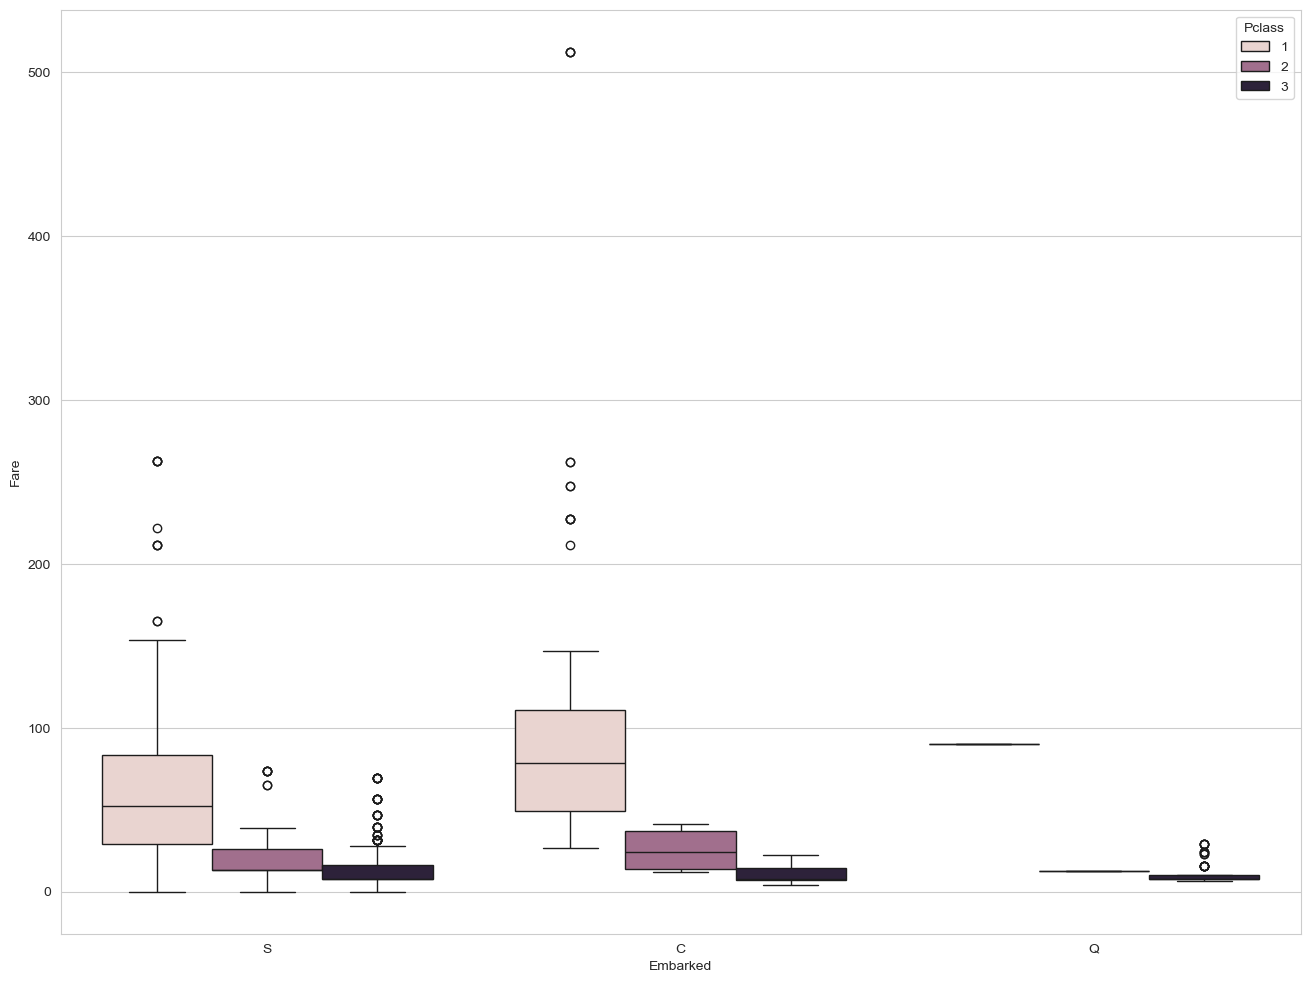

In [38]:
fig, ax = plt.subplots(figsize = (16, 12))
sns.boxplot(x = 'Embarked', y = 'Fare', hue = 'Pclass', data = df_train, ax = ax)
fig.show()

Here, the average fare closest to $80 are in the C Embarked values where Pclass is 1, let's fill in the missing values as 'C'

In [39]:
df_train['Embarked'].fillna('C', inplace = True)

2) Cabin Feature

In [40]:
print('Proportion of Missing Cabin Values in Training Set:', df_train['Cabin'].isnull().sum()/len(df_train))

Proportion of Missing Cabin Values in Training Set: 0.7710437710437711


This leads us to make a decision:
1) Get rid of the whole feature
2) Brainstorm a little and find an appropriate way to put them to use. For example, We may say  passengers with cabin record had a higher socio-economic status than others. We may also say that passengers with cabin record were more likely to be taken into consideration when loading into the boat.

However, we can check if existence of cabin data somehow relates to survival

In [41]:
have_cabin_survived = df_train[df_train['Cabin'].isna() == False]['Survived'].mean()
no_cabin_survived = df_train[df_train['Cabin'].isna() == True]['Survived'].mean()
print(f"Survival rate w cabin info: {have_cabin_survived:.2%}")
print(f"Survival rate without cabin info: {no_cabin_survived:.2%}")

Survival rate w cabin info: 66.67%
Survival rate without cabin info: 29.99%


It seems like the existence of a cabin seems correlated to survival, so we can drop cabin data and introduct a new column define the existence of a cabin

In [42]:
df_train['has_cabin'] = df_train['Cabin'].notna().astype(int)
df_train.drop(columns = ['Cabin'], inplace = True)
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,has_cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


### Age Feature
For the missing age data, let us fill in missing data with median age given gender and passenger class.
1) Groupby table that calculate the median

In [43]:
median_age = df_train.groupby(['Pclass', 'Sex'])['Age'].median().reset_index()
median_age

,Pclass,Sex,Age
0,1,female,35.0
1,1,male,40.0
2,2,female,28.0
3,2,male,30.0
4,3,female,21.5
5,3,male,25.0


In [44]:
# Fill missing entries with the median of their corresponding groups
# .transform('medianl') calculates the median age for each group, then gives each row the correct group median
df_train["Age"] = df_train["Age"].fillna(
    df_train.groupby(["Pclass", "Sex"])["Age"].transform("median")
)

In [45]:
# Check if Age still has missing values
print("Missing Age values:", df_train["Age"].isna().sum())

Missing Age values: 0


Visualizing the Age distribution after imputation

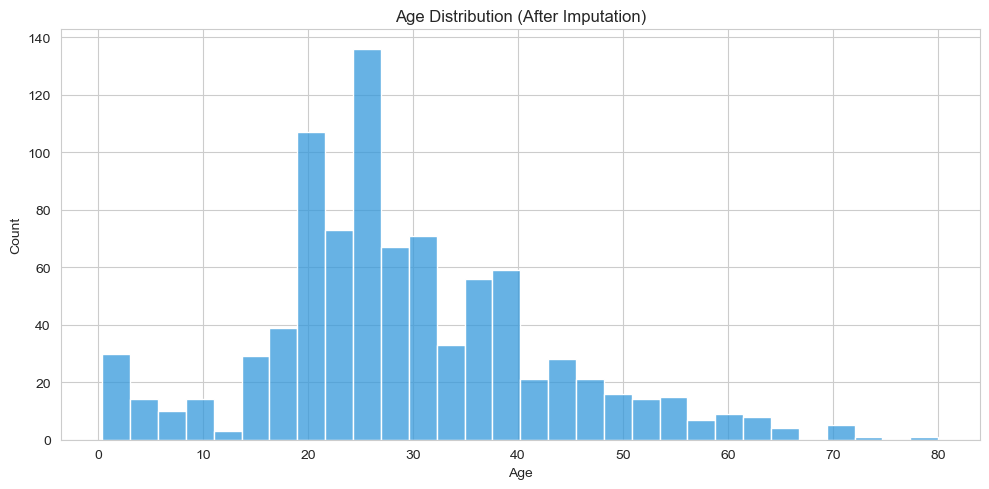

In [46]:
fig, ax = plt.subplots(figsize = (10, 5))
sns.histplot(df_train, x = 'Age', bins = 30, ax = ax, color="#3498db", edgecolor="white")
ax.set_title('Age Distribution (After Imputation)')
ax.set_xlabel('Age')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

### Final Missing Values Check before moving on to Feature Engineering

In [47]:
df_train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
has_cabin      0
dtype: int64

## Feature Engineering

### Age binning
Continuous values into categorical values by either Binning or Normalization.
- Manual bin -> In this case, we're going to separate ages into 5 bins
- use pd.qcut/pd.cut
- pd.cut parameters:
    - bins (int for equal width bins, sequence of numbers that define the bin, or interval index describing exact bins)
    - labels = [], labels for each bin, so must be the same length as bins (or one less if using the bin edges)

In [48]:
# Age binning - 5 equal bins
# Max Age = 80 -> 80/5 = 16
df_train['age_bin'] = 0
df_train.loc[df_train['Age'] <= 16, 'age_bin'] = 0
df_train.loc[(df_train['Age']>16)&(df_train['Age']<=32),'age_bin']= 1
df_train.loc[(df_train['Age']>32)&(df_train['Age']<=48),'age_bin']= 2
df_train.loc[(df_train['Age']>48)&(df_train['Age']<=64),'age_bin']= 3
df_train.loc[df_train['Age']>64, 'age_bin'] = 4

# Check # of members in each bin
print(df_train['age_bin'].value_counts().sort_index)

# Check the percentage of members in each bin
percent = round(df_train['age_bin'].value_counts(normalize = True)*100, 2).to_frame('% of values')
print(percent)

<bound method Series.sort_index of age_bin
1    493
2    218
0    100
3     69
4     11
Name: count, dtype: int64>
         % of values
age_bin             
1              55.33
2              24.47
0              11.22
3               7.74
4               1.23


### Fare binning

In [57]:
df_train['fare_bin'] = pd.qcut(df_train['Fare'], q=4, labels=[1, 2, 3, 4])

# Check # of fares in each bin
print(df_train['fare_bin'].value_counts().sort_index)

# Check the percentages of fares in each bin
percent = round(df_train['fare_bin'].value_counts(normalize = True)*100, 2).sort_index().to_frame('% of values')
print(percent)

<bound method Series.sort_index of fare_bin
2    224
1    223
3    222
4    222
Name: count, dtype: int64>
          % of values
fare_bin             
1               25.03
2               25.14
3               24.92
4               24.92


### Title Extraction

In [49]:
# Sampling some names
df_train['Name'].sample(20)

68                      Andersson, Miss. Erna Alexandra
15                     Hewlett, Mrs. (Mary D Kingcome) 
681                                  Hassab, Mr. Hammad
545                        Nicholson, Mr. Arthur Ernest
710    Mayne, Mlle. Berthe Antonine ("Mrs de Villiers")
841                            Mudd, Mr. Thomas Charles
380                               Bidois, Miss. Rosalie
840                         Alhomaki, Mr. Ilmari Rudolf
62                          Harris, Mr. Henry Birkhardt
50                           Panula, Master. Juha Niilo
624                         Bowen, Mr. David John "Dai"
543                                   Beane, Mr. Edward
738                                  Ivanoff, Mr. Kanio
94                                    Coxon, Mr. Daniel
765                Hogeboom, Mrs. John C (Anna Andrews)
16                                 Rice, Master. Eugene
203                                Youseff, Mr. Gerious
702                               Barbara, Miss.

From the sample, we can see that the title can be extracted by:
1) Splitting where the delimiter is ','
2) Splitting where the delimiter is '.' then strip

In [50]:
# Extracting the title
# Use the .apply lambda function split and strip requires operations with individual strings
df_train['title'] = df_train['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
df_train['title'].value_counts(ascending = False)


title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

The most common titles include Mr, Miss, Mrs, Master and others are rare. Therefore, we will replace the uncommon titles with 'Rare'

In [51]:
common_titles_dic = {
    'Mr':'Mr',
    'Mrs':'Mrs',
    'Miss':'Miss',
    'Master':'Master'
}
df_train['title'] = df_train['title'].apply(lambda x: common_titles_dic.get(x, 'Rare'))
print(df_train['title'].value_counts())


title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


### FamilySize and IsAlone Features

In [54]:
# Family Size (Onboard) = SibSp + Parch + 1
df_train['Family_Size'] = df_train['SibSp'] + df_train['Parch'] + 1

df_train['Is_Alone'] = (df_train['Family_Size'] == 1).astype('int')
# Alternative
#df_train['Is_Alone'] = df['FamilySize'].apply(lambda x: x == 1 else 0)
print(f"Solo travelers: {df_train['Is_Alone'].sum()} ({df_train['Is_Alone'].mean():.1%})")
print(f"\nSurvival rate - alone: {df_train[df_train['Is_Alone'] == 1]['Survived'].mean():.2%}")
print(f"Survival rate - not alone: {df_train[df_train['Is_Alone'] == 0]['Survived'].mean():.2%}")

Solo travelers: 537 (60.3%)

Survival rate - alone: 30.35%
Survival rate - not alone: 50.56%


### Final Table Statistics

In [58]:
print(f"\nFinal dataset shape: {df_train.shape}")
print(f"\nColumns: {df_train.columns.tolist()}")

# Data Set Preview and Summary Statistics
print("\nDataset preview (first 10 rows):")
print(df_train.head(10))


Final dataset shape: (891, 17)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'has_cabin', 'age_bin', 'title', 'Family_Size', 'Is_Alone', 'fare_bin']

Dataset preview (first 10 rows):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (L

In [59]:
# Dave cleaned data
df_train.to_csv('data/cleaned.csv', index = False)
print('Cleaned dataset saved to data/cleaned.csv')
df_train.head()

Cleaned dataset saved to data/cleaned.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,has_cabin,age_bin,title,Family_Size,Is_Alone,fare_bin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,1,Mr,2,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2,Mrs,2,0,4
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1,Miss,1,1,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2,Mrs,2,0,4
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,2,Mr,1,1,2
